<a href="https://colab.research.google.com/github/Vlad3159/lab7/blob/main/lab7.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [9]:
!pip install gensim

In [10]:
# 1. Импорт библиотек

import re
import string
import warnings

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from collections import Counter
from wordcloud import WordCloud

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

from gensim.models import Word2Vec

from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, Conv1D, GlobalMaxPooling1D, Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.callbacks import EarlyStopping

warnings.filterwarnings("ignore")

sns.set(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)

np.random.seed(42)

In [11]:
# 3. Информация о датасете
# 2. Загрузка датасета

df = pd.read_csv("Tweets.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 27481 entries, 0 to 27480
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   textID         27481 non-null  object
 1   text           27480 non-null  object
 2   selected_text  27480 non-null  object
 3   sentiment      27481 non-null  object
dtypes: object(4)
memory usage: 858.9+ KB


In [12]:
# 4. Первичный просмотр данных

df.describe(include="all")

,textID,text,selected_text,sentiment
count,27481,27480,27480,27481
unique,27481,27480,22463,3
top,6f7127d9d7,All this flirting going on - The ATG smiles...,good,neutral
freq,1,1,199,11118


In [13]:
# 5. Проверка пропусков

df.isnull().sum()

,0
textID,0
text,1
selected_text,1
sentiment,0


In [14]:
# 6. Проверка дубликатов

print("Количество полных дубликатов:", df.duplicated().sum())
print("Количество дубликатов по тексту:", df["text"].duplicated().sum())

Количество полных дубликатов: 0
Количество дубликатов по тексту: 0


In [15]:
# 7. Оставляем только нужные столбцы

data = df[["text", "sentiment"]].copy()
data.head()

,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


In [16]:
# 8. Удаление пропусков и пустых строк

data = data.dropna(subset=["text", "sentiment"]).copy()
data["text"] = data["text"].astype(str)

data = data[data["text"].str.strip() != ""].copy()

print("Размер после удаления пропусков:", data.shape)
data.head()

Размер после удаления пропусков: (27480, 2)


,text,sentiment
0,"I`d have responded, if I were going",neutral
1,Sooo SAD I will miss you here in San Diego!!!,negative
2,my boss is bullying me...,negative
3,what interview! leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",negative


sentiment
neutral     11117
positive     8582
negative     7781
Name: count, dtype: int64


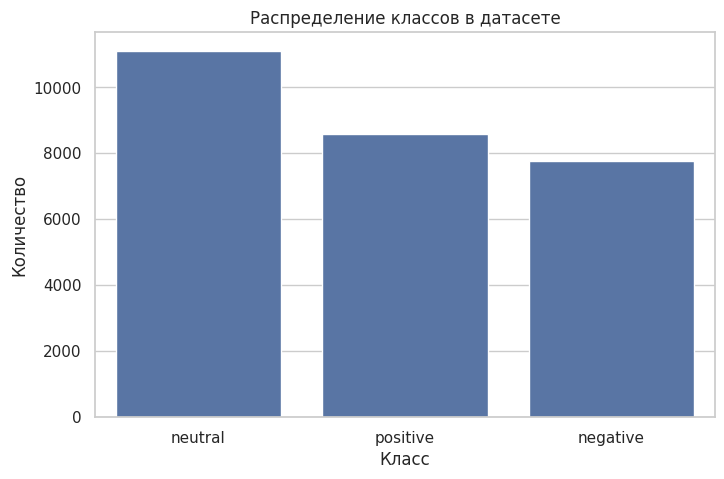

In [17]:
# 9. Распределение классов

print(data["sentiment"].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(data=data, x="sentiment", order=data["sentiment"].value_counts().index)
plt.title("Распределение классов в датасете")
plt.xlabel("Класс")
plt.ylabel("Количество")
plt.show()

In [18]:
# 10. Доли классов в процентах

class_percent = data["sentiment"].value_counts(normalize=True) * 100
print(class_percent.round(2))

sentiment
neutral     40.45
positive    31.23
negative    28.32
Name: proportion, dtype: float64


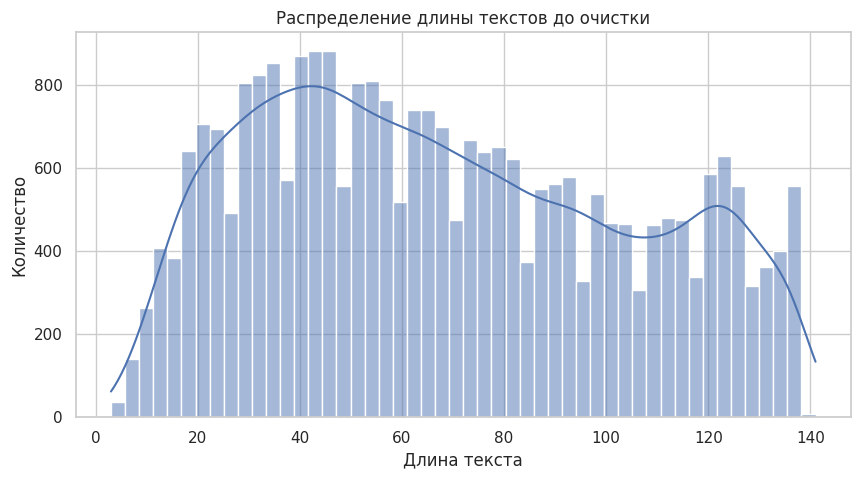

In [19]:
# 11. Длина текстов до очистки

data["text_len_before"] = data["text"].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(data["text_len_before"], bins=50, kde=True)
plt.title("Распределение длины текстов до очистки")
plt.xlabel("Длина текста")
plt.ylabel("Количество")
plt.show()

In [20]:
# 12. Функция очистки текста

def clean_text(text):
    text = text.lower()
    text = re.sub(r"http\S+|www\S+", " ", text)
    text = re.sub(r"@\w+", " ", text)
    text = re.sub(r"#(\w+)", r"\1", text)
    text = re.sub(r"&amp;", " and ", text)
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text

In [21]:
# 13. Очистка текста

data["clean_text"] = data["text"].apply(clean_text)

data[["text", "clean_text", "sentiment"]].head(10)

,text,clean_text,sentiment
0,"I`d have responded, if I were going",i d have responded if i were going,neutral
1,Sooo SAD I will miss you here in San Diego!!!,sooo sad i will miss you here in san diego,negative
2,my boss is bullying me...,my boss is bullying me,negative
3,what interview! leave me alone,what interview leave me alone,negative
4,"Sons of ****, why couldn`t they put them on t...",sons of why couldn t they put them on the rele...,negative
5,http://www.dothebouncy.com/smf - some shameles...,some shameless plugging for the best rangers f...,neutral
6,2am feedings for the baby are fun when he is a...,am feedings for the baby are fun when he is al...,positive
7,Soooo high,soooo high,neutral
8,Both of you,both of you,neutral
9,Journey!? Wow... u just became cooler. hehe....,journey wow u just became cooler hehe is that ...,positive


In [22]:
# 14. Проверка пустых текстов после очистки

print("Пустых текстов после очистки:", (data["clean_text"].str.strip() == "").sum())
data = data[data["clean_text"].str.strip() != ""].copy()

print("Размер датасета после очистки:", data.shape)

Пустых текстов после очистки: 4
Размер датасета после очистки: (27476, 4)


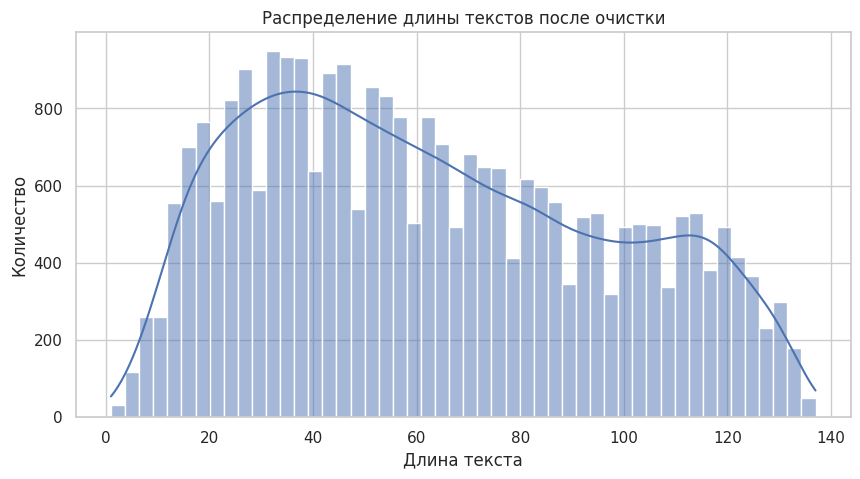

In [23]:
# 15. Длина текстов после очистки

data["text_len_after"] = data["clean_text"].apply(len)

plt.figure(figsize=(10, 5))
sns.histplot(data["text_len_after"], bins=50, kde=True)
plt.title("Распределение длины текстов после очистки")
plt.xlabel("Длина текста")
plt.ylabel("Количество")
plt.show()

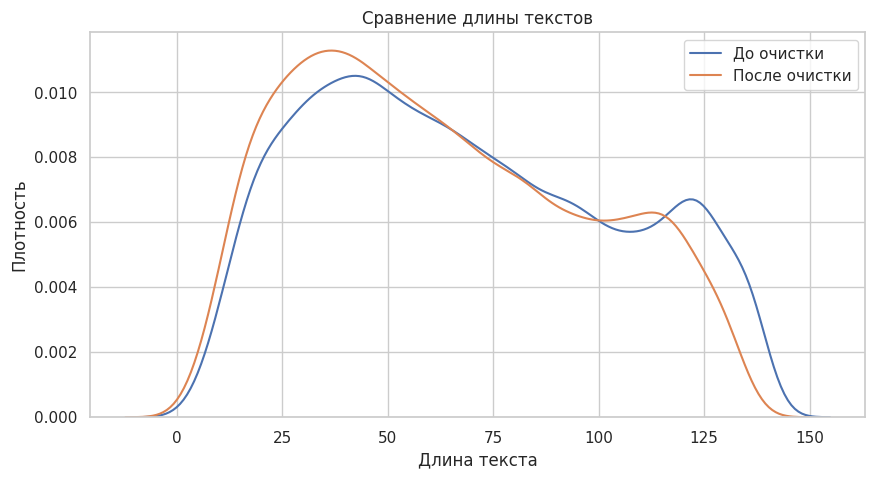

In [24]:
# 16. Сравнение длины текстов до и после очистки

plt.figure(figsize=(10, 5))
sns.kdeplot(data["text_len_before"], label="До очистки")
sns.kdeplot(data["text_len_after"], label="После очистки")
plt.title("Сравнение длины текстов")
plt.xlabel("Длина текста")
plt.ylabel("Плотность")
plt.legend()
plt.show()

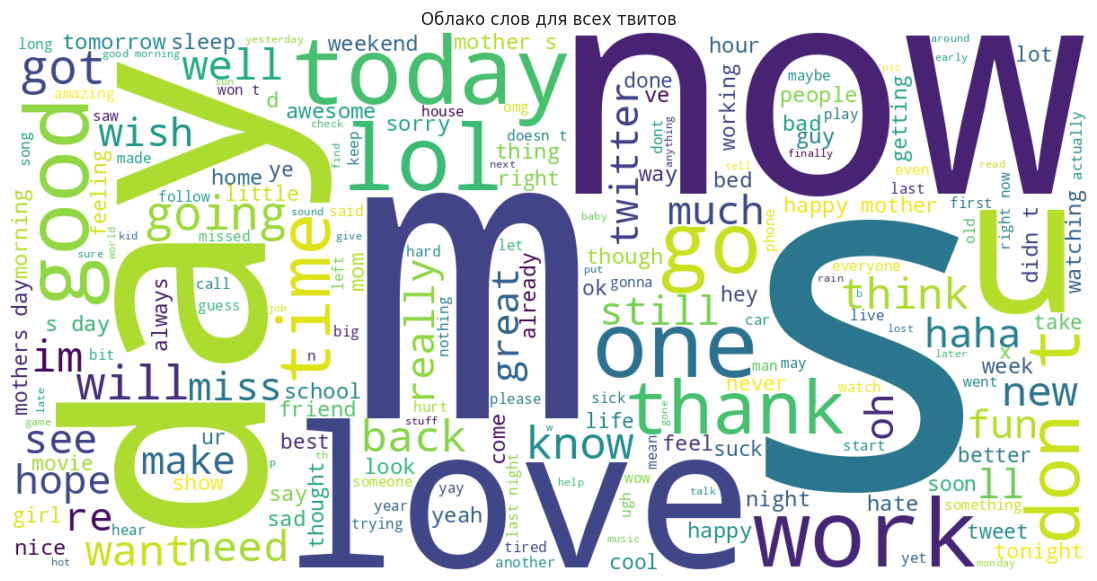

In [25]:
# 17. Общий WordCloud

all_words = " ".join(data["clean_text"])

wordcloud = WordCloud(
    width=1200,
    height=600,
    background_color="white",
    max_words=200
).generate(all_words)

plt.figure(figsize=(14, 7))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Облако слов для всех твитов")
plt.show()

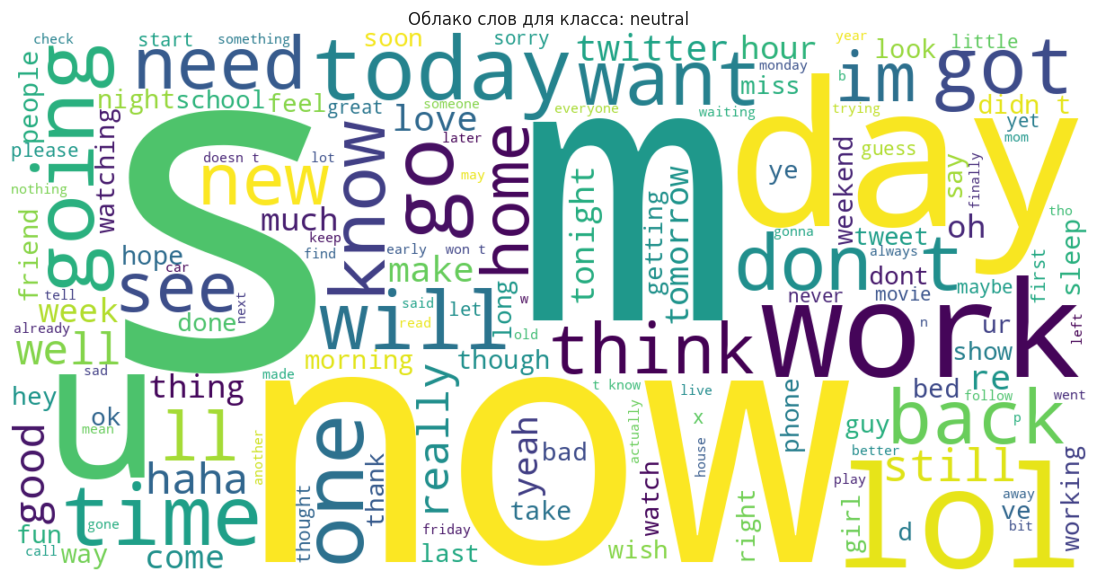

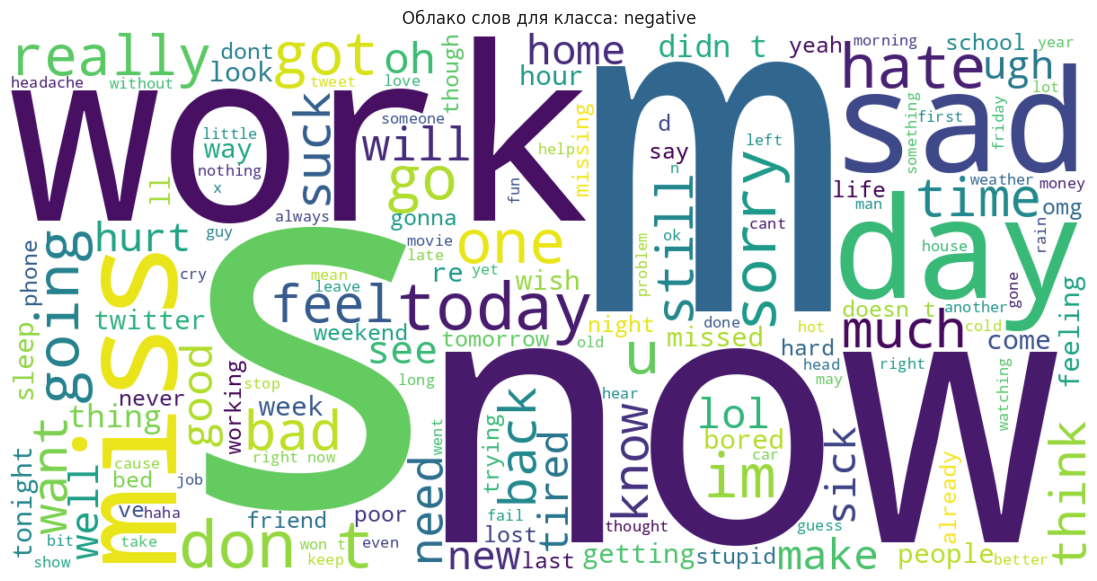

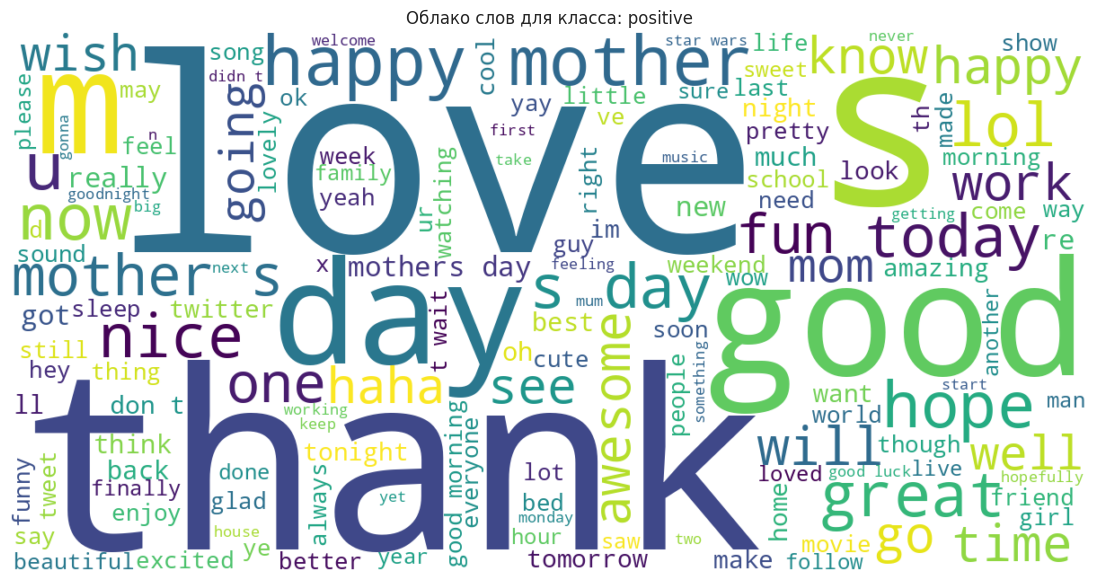

In [26]:
# 18. WordCloud по классам

sentiments = data["sentiment"].unique()

for sentiment in sentiments:
    text_class = " ".join(data.loc[data["sentiment"] == sentiment, "clean_text"])

    wordcloud = WordCloud(
        width=1200,
        height=600,
        background_color="white",
        max_words=150
    ).generate(text_class)

    plt.figure(figsize=(14, 7))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Облако слов для класса: {sentiment}")
    plt.show()

    word  count
0      i  16712
1     to  10031
2    the   9038
3      a   6896
4     my   5549
5     it   5417
6    you   5355
7    and   5168
8     is   3988
9     in   3820
10     s   3695
11   for   3658
12     t   3175
13    of   3161
14  that   3017
15    on   2870
16    me   2846
17    so   2630
18  have   2602
19   but   2409


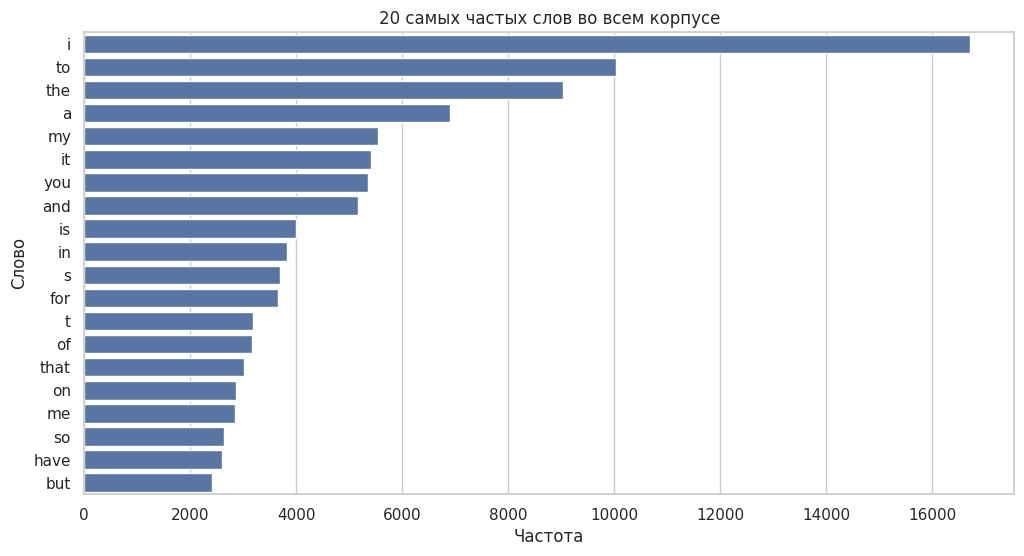

In [27]:
# 19. Самые частые слова во всем корпусе

all_tokens = " ".join(data["clean_text"]).split()
token_counts = Counter(all_tokens)

top_words = pd.DataFrame(token_counts.most_common(20), columns=["word", "count"])
print(top_words)

plt.figure(figsize=(12, 6))
sns.barplot(data=top_words, x="count", y="word")
plt.title("20 самых частых слов во всем корпусе")
plt.xlabel("Частота")
plt.ylabel("Слово")
plt.show()

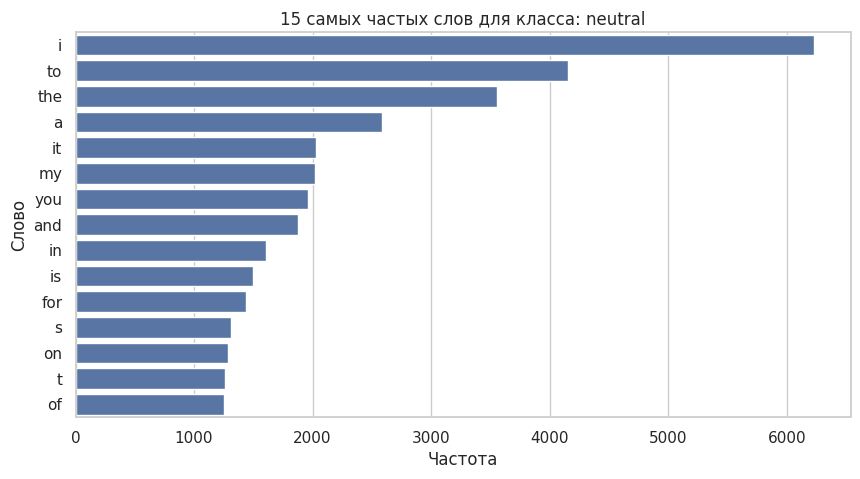

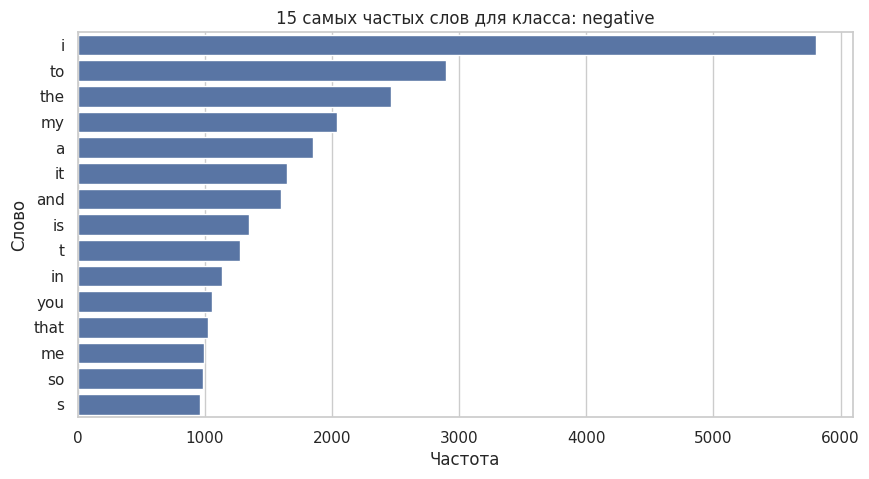

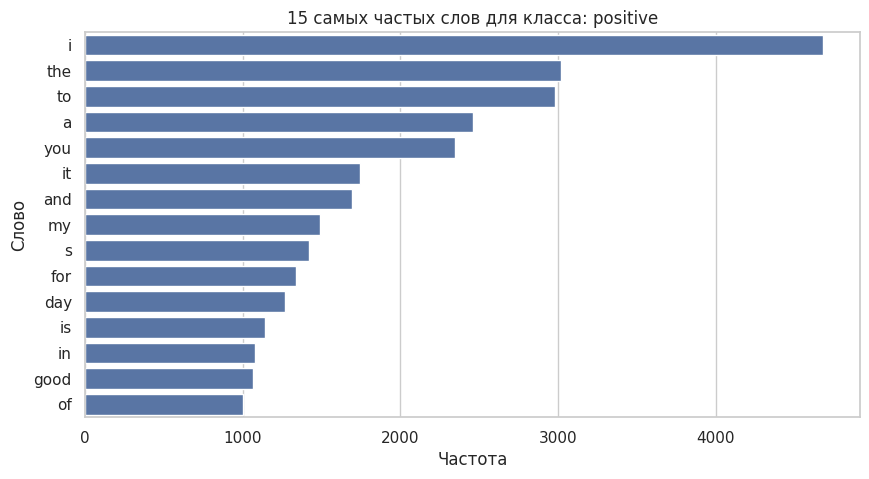

In [28]:
# 20. Самые частые слова по каждому классу

for sentiment in data["sentiment"].unique():
    tokens = " ".join(data.loc[data["sentiment"] == sentiment, "clean_text"]).split()
    counts = Counter(tokens)
    top_class_words = pd.DataFrame(counts.most_common(15), columns=["word", "count"])

    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_class_words, x="count", y="word")
    plt.title(f"15 самых частых слов для класса: {sentiment}")
    plt.xlabel("Частота")
    plt.ylabel("Слово")
    plt.show()

In [29]:
# 21. Кодирование целевой переменной

label_encoder = LabelEncoder()
data["label"] = label_encoder.fit_transform(data["sentiment"])

print("Классы:", list(label_encoder.classes_))
data[["sentiment", "label"]].drop_duplicates().sort_values("label")

Классы: ['negative', 'neutral', 'positive']


,sentiment,label
1,negative,0
0,neutral,1
6,positive,2


In [30]:
# 22. Разделение на обучающую и тестовую выборки

X = data["clean_text"]
y = data["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Размер X_train:", X_train.shape)
print("Размер X_test:", X_test.shape)
print("Распределение классов в y_train:")
print(pd.Series(y_train).value_counts())
print("Распределение классов в y_test:")
print(pd.Series(y_test).value_counts())

Размер X_train: (21980,)
Размер X_test: (5496,)
Распределение классов в y_train:
label
1    8891
2    6865
0    6224
Name: count, dtype: int64
Распределение классов в y_test:
label
1    2223
2    1717
0    1556
Name: count, dtype: int64


In [31]:
# 23. Функция для расчета метрик

def get_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, average="weighted")
    rec = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")

    print("Accuracy :", round(acc, 4))
    print("Precision:", round(prec, 4))
    print("Recall   :", round(rec, 4))
    print("F1-score :", round(f1, 4))

In [32]:
# 24. Функция визуализации матрицы ошибок

def plot_conf_matrix(y_true, y_pred, class_names, title):
    cm = confusion_matrix(y_true, y_pred)
    cm_df = pd.DataFrame(cm, index=class_names, columns=class_names)

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_df, annot=True, fmt="d", cmap="Blues")
    plt.title(title)
    plt.xlabel("Предсказанный класс")
    plt.ylabel("Истинный класс")
    plt.show()

In [33]:
# 25. Bag of Words

count_vectorizer = CountVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_counts = count_vectorizer.fit_transform(X_train)
X_test_counts = count_vectorizer.transform(X_test)

print("Размер матрицы признаков train:", X_train_counts.shape)
print("Размер матрицы признаков test :", X_test_counts.shape)

Размер матрицы признаков train: (21980, 10000)
Размер матрицы признаков test : (5496, 10000)


In [34]:
# 26. Обучение Logistic Regression на Bag of Words

clf_counts = LogisticRegression(
    C=10,
    class_weight="balanced",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

clf_counts.fit(X_train_counts, y_train)
y_pred_counts = clf_counts.predict(X_test_counts)

In [35]:
# 27. Метрики Bag of Words

print("Bag of Words + Logistic Regression")
get_metrics(y_test, y_pred_counts)

print("\nClassification report:")
print(classification_report(y_test, y_pred_counts, target_names=label_encoder.classes_))

Bag of Words + Logistic Regression
Accuracy : 0.6386
Precision: 0.6391
Recall   : 0.6386
F1-score : 0.6388

Classification report:
              precision    recall  f1-score   support

    negative       0.63      0.62      0.62      1556
     neutral       0.60      0.61      0.60      2223
    positive       0.70      0.70      0.70      1717

    accuracy                           0.64      5496
   macro avg       0.64      0.64      0.64      5496
weighted avg       0.64      0.64      0.64      5496



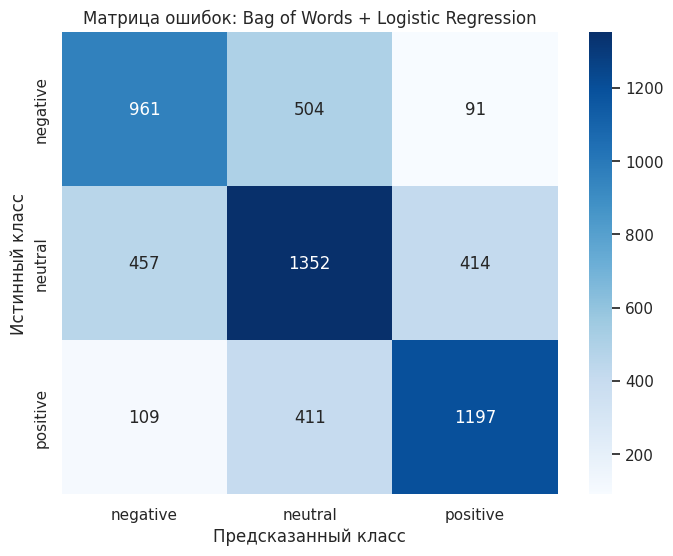

In [36]:
# 28. Матрица ошибок для Bag of Words

plot_conf_matrix(
    y_test,
    y_pred_counts,
    class_names=label_encoder.classes_,
    title="Матрица ошибок: Bag of Words + Logistic Regression"
)

In [37]:
# 29. TF-IDF векторизация

tfidf_vectorizer = TfidfVectorizer(
    max_features=10000,
    ngram_range=(1, 2),
    min_df=2
)

X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)

print("Размер TF-IDF матрицы train:", X_train_tfidf.shape)
print("Размер TF-IDF матрицы test :", X_test_tfidf.shape)

Размер TF-IDF матрицы train: (21980, 10000)
Размер TF-IDF матрицы test : (5496, 10000)


In [38]:
# 30. Обучение Logistic Regression на TF-IDF

clf_tfidf = LogisticRegression(
    C=10,
    class_weight="balanced",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

clf_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = clf_tfidf.predict(X_test_tfidf)

In [39]:
# 31. Метрики TF-IDF

print("TF-IDF + Logistic Regression")
get_metrics(y_test, y_pred_tfidf)

print("\nClassification report:")
print(classification_report(y_test, y_pred_tfidf, target_names=label_encoder.classes_))

TF-IDF + Logistic Regression
Accuracy : 0.6667
Precision: 0.6671
Recall   : 0.6667
F1-score : 0.6669

Classification report:
              precision    recall  f1-score   support

    negative       0.65      0.65      0.65      1556
     neutral       0.62      0.63      0.63      2223
    positive       0.74      0.73      0.73      1717

    accuracy                           0.67      5496
   macro avg       0.67      0.67      0.67      5496
weighted avg       0.67      0.67      0.67      5496



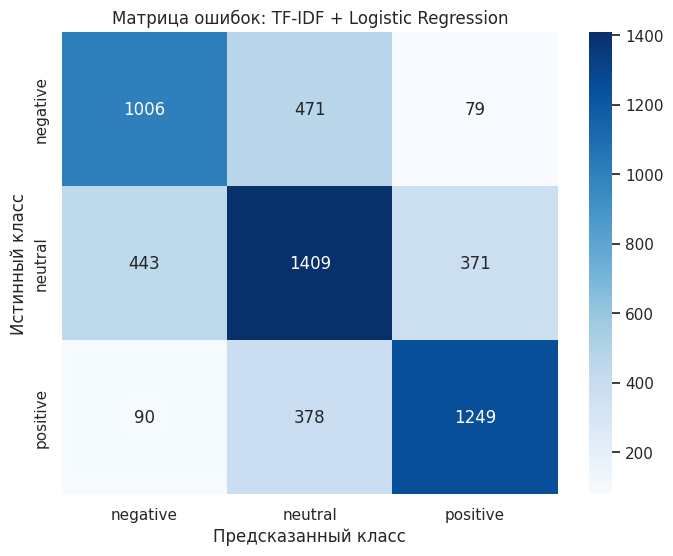

In [40]:
# 32. Матрица ошибок для TF-IDF

plot_conf_matrix(
    y_test,
    y_pred_tfidf,
    class_names=label_encoder.classes_,
    title="Матрица ошибок: TF-IDF + Logistic Regression"
)

In [41]:
# 33. Сравнение Bag of Words и TF-IDF

results_classic = pd.DataFrame({
    "Метод": ["Bag of Words", "TF-IDF"],
    "Accuracy": [
        accuracy_score(y_test, y_pred_counts),
        accuracy_score(y_test, y_pred_tfidf)
    ],
    "Precision": [
        precision_score(y_test, y_pred_counts, average="weighted"),
        precision_score(y_test, y_pred_tfidf, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_counts, average="weighted"),
        recall_score(y_test, y_pred_tfidf, average="weighted")
    ],
    "F1-score": [
        f1_score(y_test, y_pred_counts, average="weighted"),
        f1_score(y_test, y_pred_tfidf, average="weighted")
    ]
})

results_classic.round(4)

,Метод,Accuracy,Precision,Recall,F1-score
0,Bag of Words,0.6386,0.6391,0.6386,0.6388
1,TF-IDF,0.6667,0.6671,0.6667,0.6669


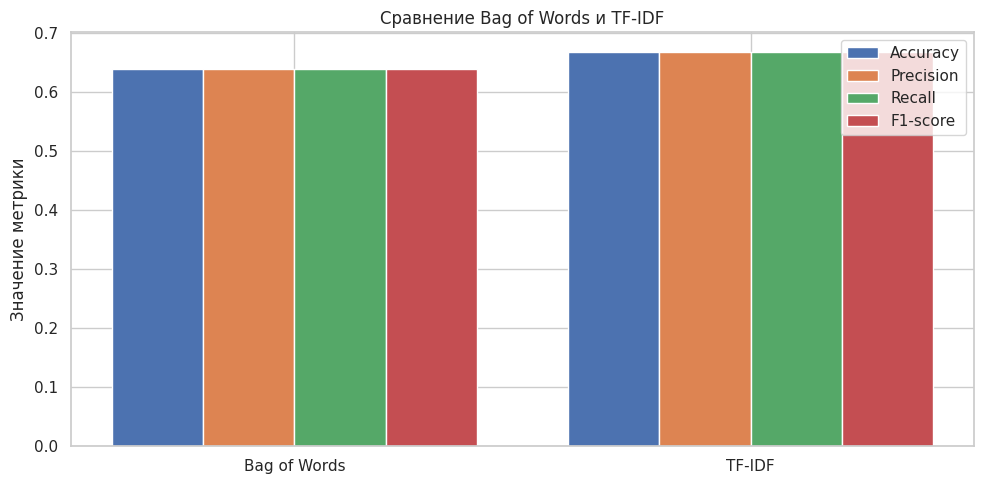

In [42]:
# 34. Финальный график сравнения классических методов

plot_df = results_classic.copy()

plt.figure(figsize=(10, 5))
x = np.arange(len(plot_df))
width = 0.2

plt.bar(x - 1.5 * width, plot_df["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5 * width, plot_df["Precision"], width, label="Precision")
plt.bar(x + 0.5 * width, plot_df["Recall"], width, label="Recall")
plt.bar(x + 1.5 * width, plot_df["F1-score"], width, label="F1-score")

plt.xticks(x, plot_df["Метод"])
plt.ylabel("Значение метрики")
plt.title("Сравнение Bag of Words и TF-IDF")
plt.legend()
plt.tight_layout()
plt.show()

In [43]:
# 35. Важные признаки для TF-IDF модели

feature_names = np.array(tfidf_vectorizer.get_feature_names_out())

for class_index, class_name in enumerate(label_encoder.classes_):
    coef = clf_tfidf.coef_[class_index]
    top_positive = feature_names[np.argsort(coef)[-15:]][::-1]
    top_negative = feature_names[np.argsort(coef)[:15]]

    print(f"\nКласс: {class_name}")
    print("Наиболее важные положительные признаки:")
    print(top_positive)
    print("Наименее важные признаки:")
    print(top_negative)


Класс: negative
Наиболее важные положительные признаки:
['sad' 'sucks' 'sorry' 'hate' 'not good' 'fail' 'sick' 'stupid' 'miss'
 'no fun' 'tired' 'headache' 'not happy' 'boring' 'terrible']
Наименее важные признаки:
['love' 'awesome' 'hopefully' 'glad' 'hope' 'amazing' 'thank' 'thanks'
 'great' 'happy' 'good' 'nice' 'cute' 'beautiful' 'good times']

Класс: neutral
Наиболее важные положительные признаки:
['sucks but' 'glad it' 'but yeah' 'jealous of' 'indoors' 'jst' 'otherwise'
 'moro' 'training' 'hear the' 'theres' 'me from' 'sick but' 'sp'
 'these days']
Наименее важные признаки:
['happy' 'love' 'good' 'awesome' 'thanks' 'stupid' 'nice' 'amazing'
 'congratulations' 'enjoy' 'fail' 'wtf' 'great' 'sucks' 'wonderful']

Класс: positive
Наиболее важные положительные признаки:
['love' 'awesome' 'happy' 'good' 'nice' 'thanks' 'amazing' 'great'
 'lovely' 'enjoy' 'cute' 'fun' 'thank' 'excited' 'best']
Наименее важные признаки:
['sad' 'sorry' 'sucks' 'tired' 'hate' 'bored' 'miss' 'missed' 'not g

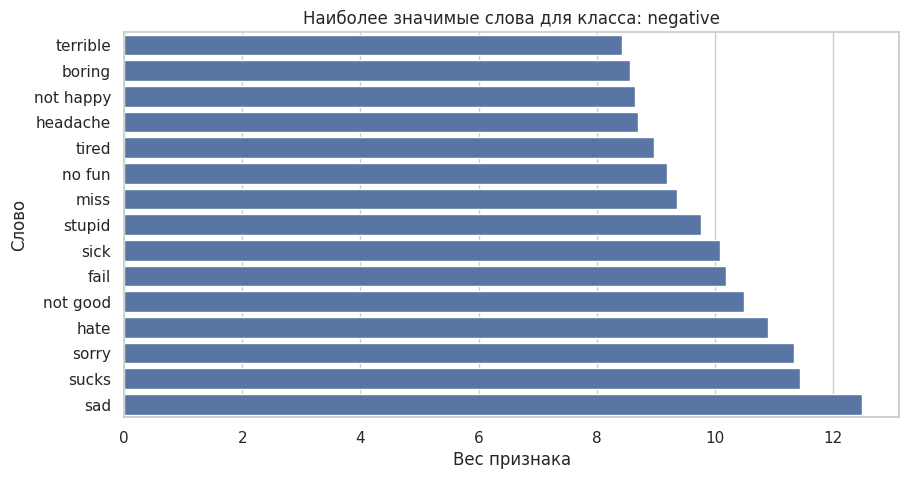

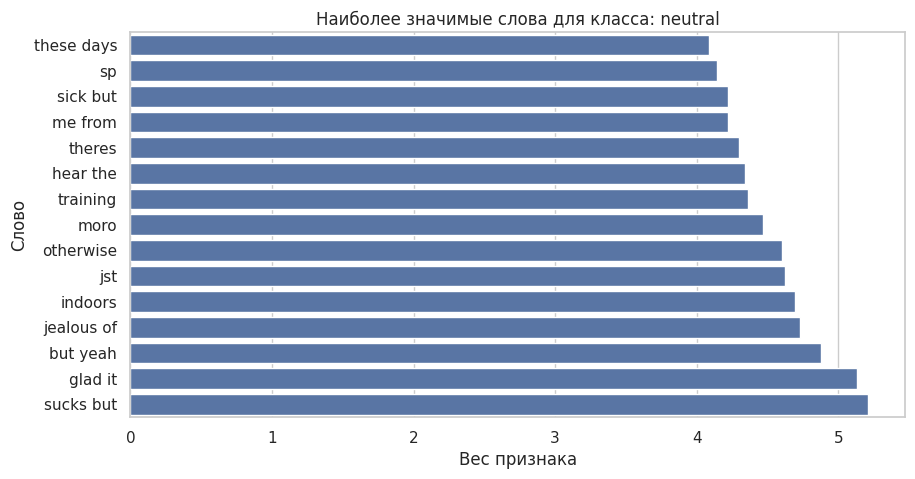

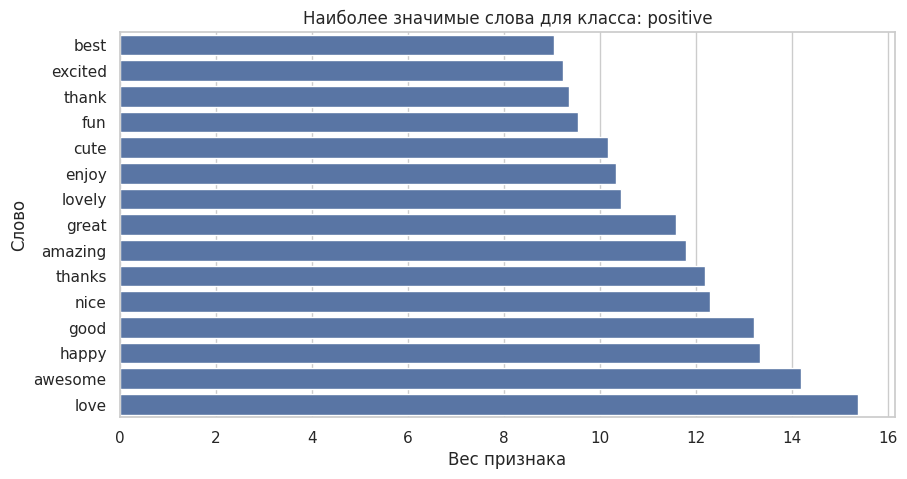

In [44]:
# 36. Визуализация наиболее значимых слов для каждого класса

for class_index, class_name in enumerate(label_encoder.classes_):
    coef = clf_tfidf.coef_[class_index]
    top_idx = np.argsort(coef)[-15:]

    top_words = feature_names[top_idx]
    top_values = coef[top_idx]

    top_df = pd.DataFrame({
        "word": top_words,
        "coef": top_values
    }).sort_values("coef", ascending=True)

    plt.figure(figsize=(10, 5))
    sns.barplot(data=top_df, x="coef", y="word")
    plt.title(f"Наиболее значимые слова для класса: {class_name}")
    plt.xlabel("Вес признака")
    plt.ylabel("Слово")
    plt.show()

In [45]:
# 37. Подготовка токенов для Word2Vec

tokenized_texts = data["clean_text"].apply(str.split).tolist()

print("Пример токенизации:")
print(tokenized_texts[0][:20])

Пример токенизации:
['i', 'd', 'have', 'responded', 'if', 'i', 'were', 'going']


In [46]:
# 38. Обучение Word2Vec

w2v_model = Word2Vec(
    sentences=tokenized_texts,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4,
    sg=1,
    epochs=15
)

print("Размер словаря Word2Vec:", len(w2v_model.wv))

Размер словаря Word2Vec: 10054


In [47]:
# 39. Проверка похожих слов Word2Vec

sample_words = ["good", "bad", "love", "sad", "happy"]

for word in sample_words:
    if word in w2v_model.wv:
        print(f"\nПохожие слова для '{word}':")
        print(w2v_model.wv.most_similar(word, topn=5))


Похожие слова для 'good':
[('goooood', 0.6612364649772644), ('animation', 0.6532779932022095), ('blessed', 0.6472474932670593), ('goooooood', 0.641654908657074), ('decent', 0.6348164081573486)]

Похожие слова для 'bad':
[('uncomfortable', 0.5873405337333679), ('obviously', 0.5860137343406677), ('pets', 0.5773274898529053), ('quickly', 0.5755531191825867), ('shaved', 0.5646936893463135)]

Похожие слова для 'love':
[('adore', 0.5985954999923706), ('loved', 0.5804814100265503), ('adorable', 0.5503989458084106), ('ilove', 0.5495089888572693), ('appreciate', 0.539690375328064)]

Похожие слова для 'sad':
[('disappointed', 0.6126243472099304), ('depressed', 0.5925045013427734), ('confused', 0.5823173522949219), ('ugly', 0.568509578704834), ('bummed', 0.5679101943969727)]

Похожие слова для 'happy':
[('mother', 0.6891199946403503), ('mothers', 0.6871387362480164), ('mommies', 0.6824098825454712), ('momma', 0.6768203377723694), ('mamas', 0.6669740676879883)]


In [48]:
# 40. Функция получения вектора предложения через усреднение Word2Vec

def document_vector(doc, model):
    words = [word for word in doc.split() if word in model.wv]
    if len(words) == 0:
        return np.zeros(model.vector_size)
    return np.mean(model.wv[words], axis=0)

In [49]:
# 41. Построение эмбеддингов документов

X_w2v = np.array([document_vector(text, w2v_model) for text in data["clean_text"]])

print("Форма массива эмбеддингов:", X_w2v.shape)

Форма массива эмбеддингов: (27476, 100)


In [50]:
# 42. Разделение данных для Word2Vec модели

y_all = data["label"].values

X_train_w2v, X_test_w2v, y_train_w2v, y_test_w2v = train_test_split(
    X_w2v,
    y_all,
    test_size=0.2,
    random_state=42,
    stratify=y_all
)

print("X_train_w2v:", X_train_w2v.shape)
print("X_test_w2v :", X_test_w2v.shape)

X_train_w2v: (21980, 100)
X_test_w2v : (5496, 100)


In [51]:
# 43. Logistic Regression на Word2Vec эмбеддингах

clf_w2v = LogisticRegression(
    C=10,
    class_weight="balanced",
    solver="liblinear",
    max_iter=1000,
    random_state=42
)

clf_w2v.fit(X_train_w2v, y_train_w2v)
y_pred_w2v = clf_w2v.predict(X_test_w2v)

In [52]:
# 44. Метрики Word2Vec модели

print("Word2Vec + Logistic Regression")
get_metrics(y_test_w2v, y_pred_w2v)

print("\nClassification report:")
print(classification_report(y_test_w2v, y_pred_w2v, target_names=label_encoder.classes_))

Word2Vec + Logistic Regression
Accuracy : 0.6112
Precision: 0.6111
Recall   : 0.6112
F1-score : 0.6111

Classification report:
              precision    recall  f1-score   support

    negative       0.59      0.58      0.58      1556
     neutral       0.58      0.59      0.59      2223
    positive       0.66      0.67      0.66      1717

    accuracy                           0.61      5496
   macro avg       0.61      0.61      0.61      5496
weighted avg       0.61      0.61      0.61      5496



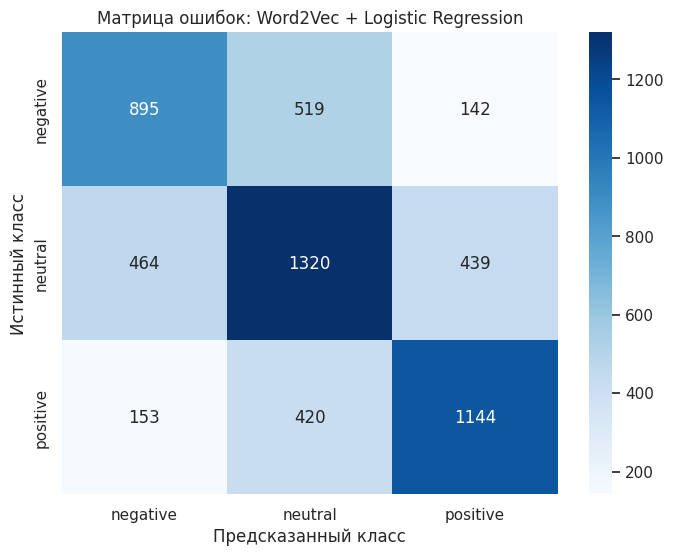

In [53]:
# 45. Матрица ошибок для Word2Vec модели

plot_conf_matrix(
    y_test_w2v,
    y_pred_w2v,
    class_names=label_encoder.classes_,
    title="Матрица ошибок: Word2Vec + Logistic Regression"
)

In [54]:
# 46. Сравнение трех подходов

results_all = pd.DataFrame({
    "Метод": [
        "Bag of Words + LR",
        "TF-IDF + LR",
        "Word2Vec + LR"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_counts),
        accuracy_score(y_test, y_pred_tfidf),
        accuracy_score(y_test_w2v, y_pred_w2v)
    ],
    "Precision": [
        precision_score(y_test, y_pred_counts, average="weighted"),
        precision_score(y_test, y_pred_tfidf, average="weighted"),
        precision_score(y_test_w2v, y_pred_w2v, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_counts, average="weighted"),
        recall_score(y_test, y_pred_tfidf, average="weighted"),
        recall_score(y_test_w2v, y_pred_w2v, average="weighted")
    ],
    "F1-score": [
        f1_score(y_test, y_pred_counts, average="weighted"),
        f1_score(y_test, y_pred_tfidf, average="weighted"),
        f1_score(y_test_w2v, y_pred_w2v, average="weighted")
    ]
})

results_all.round(4)

,Метод,Accuracy,Precision,Recall,F1-score
0,Bag of Words + LR,0.6386,0.6391,0.6386,0.6388
1,TF-IDF + LR,0.6667,0.6671,0.6667,0.6669
2,Word2Vec + LR,0.6112,0.6111,0.6112,0.6111


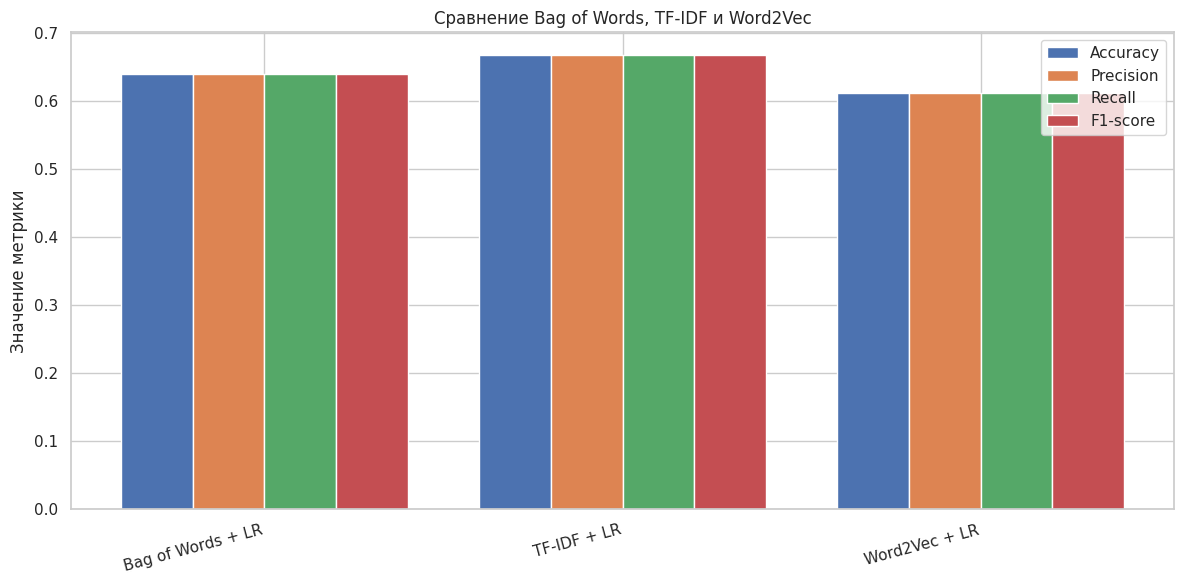

In [55]:
# 47. Финальный график сравнения трех подходов

plot_df = results_all.copy()

plt.figure(figsize=(12, 6))
x = np.arange(len(plot_df))
width = 0.2

plt.bar(x - 1.5 * width, plot_df["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5 * width, plot_df["Precision"], width, label="Precision")
plt.bar(x + 0.5 * width, plot_df["Recall"], width, label="Recall")
plt.bar(x + 1.5 * width, plot_df["F1-score"], width, label="F1-score")

plt.xticks(x, plot_df["Метод"], rotation=15, ha="right")
plt.ylabel("Значение метрики")
plt.title("Сравнение Bag of Words, TF-IDF и Word2Vec")
plt.legend()
plt.tight_layout()
plt.show()

In [56]:
# 48. Подготовка данных для нейросети

max_words = 20000
max_len = 40

tokenizer = Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(data["clean_text"])

sequences = tokenizer.texts_to_sequences(data["clean_text"])
X_seq = pad_sequences(sequences, maxlen=max_len, padding="post", truncating="post")

y_nn = to_categorical(data["label"])

X_train_nn, X_test_nn, y_train_nn, y_test_nn = train_test_split(
    X_seq,
    y_nn,
    test_size=0.2,
    random_state=42,
    stratify=data["label"]
)

print("Форма X_train_nn:", X_train_nn.shape)
print("Форма X_test_nn :", X_test_nn.shape)

Форма X_train_nn: (21980, 40)
Форма X_test_nn : (5496, 40)


In [57]:
# 49. Построение end-to-end нейросети

num_classes = y_nn.shape[1]

model = Sequential([
    Embedding(input_dim=max_words, output_dim=128, input_length=max_len),
    Conv1D(128, 5, activation="relu"),
    GlobalMaxPooling1D(),
    Dropout(0.3),
    Dense(64, activation="relu"),
    Dropout(0.3),
    Dense(num_classes, activation="softmax")
])

model.compile(
    loss="categorical_crossentropy",
    optimizer="adam",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d (Conv1D)                 │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_max_pooling1d            │ ?                      │             0 │
│ (GlobalMaxPooling1D)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [58]:
# 50. Обучение нейросети

early_stop = EarlyStopping(
    monitor="val_loss",
    patience=2,
    restore_best_weights=True
)

history = model.fit(
    X_train_nn,
    y_train_nn,
    validation_split=0.2,
    epochs=8,
    batch_size=64,
    callbacks=[early_stop],
    verbose=1
)

Epoch 1/8
275/275 ━━━━━━━━━━━━━━━━━━━━ 17s 54ms/step - accuracy: 0.5655 - loss: 0.8953 - val_accuracy: 0.7182 - val_loss: 0.6686
Epoch 2/8
275/275 ━━━━━━━━━━━━━━━━━━━━ 15s 55ms/step - accuracy: 0.7610 - loss: 0.5948 - val_accuracy: 0.7311 - val_loss: 0.6425
Epoch 3/8
275/275 ━━━━━━━━━━━━━━━━━━━━ 21s 56ms/step - accuracy: 0.8483 - loss: 0.4033 - val_accuracy: 0.7045 - val_loss: 0.7117
Epoch 4/8
275/275 ━━━━━━━━━━━━━━━━━━━━ 15s 56ms/step - accuracy: 0.9104 - loss: 0.2525 - val_accuracy: 0.7100 - val_loss: 0.8017


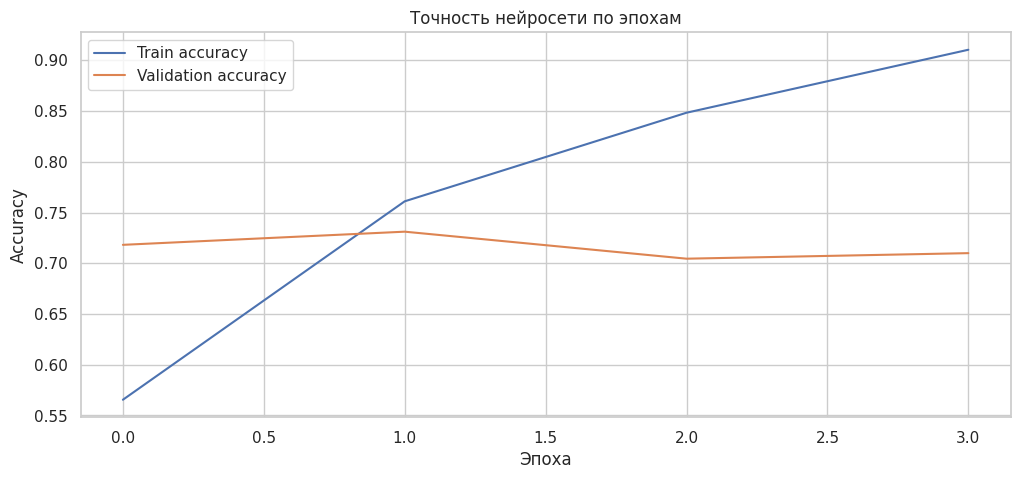

In [59]:
# 51. График обучения нейросети

plt.figure(figsize=(12, 5))
plt.plot(history.history["accuracy"], label="Train accuracy")
plt.plot(history.history["val_accuracy"], label="Validation accuracy")
plt.title("Точность нейросети по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

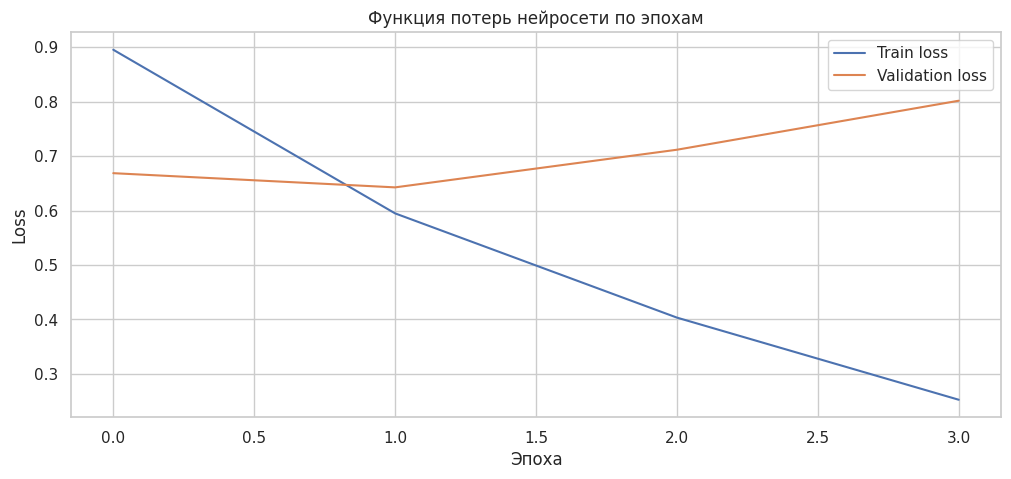

In [60]:
# 52. График функции потерь нейросети

plt.figure(figsize=(12, 5))
plt.plot(history.history["loss"], label="Train loss")
plt.plot(history.history["val_loss"], label="Validation loss")
plt.title("Функция потерь нейросети по эпохам")
plt.xlabel("Эпоха")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [61]:
# 53. Оценка нейросети на тестовой выборке

test_loss, test_acc = model.evaluate(X_test_nn, y_test_nn, verbose=0)

print("Test loss:", round(test_loss, 4))
print("Test accuracy:", round(test_acc, 4))

Test loss: 0.6726
Test accuracy: 0.7154


In [62]:
# 54. Предсказания нейросети

y_pred_nn_prob = model.predict(X_test_nn)
y_pred_nn = np.argmax(y_pred_nn_prob, axis=1)
y_true_nn = np.argmax(y_test_nn, axis=1)

print("Нейросеть CNN")
get_metrics(y_true_nn, y_pred_nn)

print("\nClassification report:")
print(classification_report(y_true_nn, y_pred_nn, target_names=label_encoder.classes_))

172/172 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step
Нейросеть CNN
Accuracy : 0.7154
Precision: 0.7236
Recall   : 0.7154
F1-score : 0.7152

Classification report:
              precision    recall  f1-score   support

    negative       0.76      0.61      0.68      1556
     neutral       0.65      0.76      0.70      2223
    positive       0.79      0.76      0.77      1717

    accuracy                           0.72      5496
   macro avg       0.73      0.71      0.72      5496
weighted avg       0.72      0.72      0.72      5496



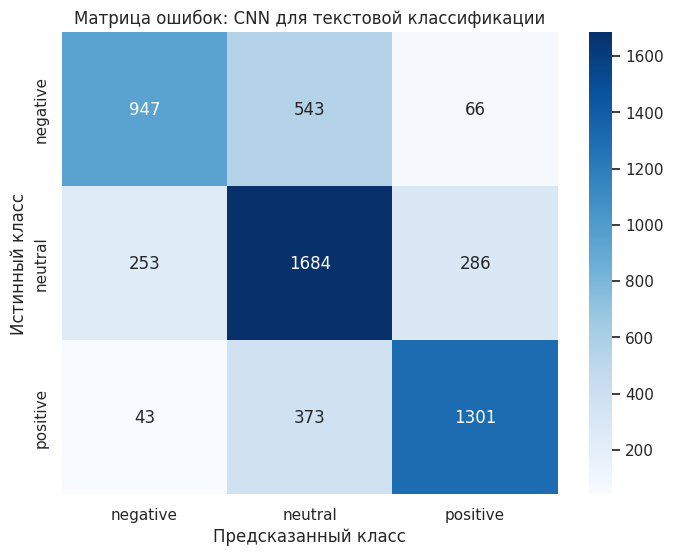

In [63]:
# 55. Матрица ошибок нейросети

plot_conf_matrix(
    y_true_nn,
    y_pred_nn,
    class_names=label_encoder.classes_,
    title="Матрица ошибок: CNN для текстовой классификации"
)

In [64]:
# 56. Итоговое сравнение всех моделей

results_final = pd.DataFrame({
    "Метод": [
        "Bag of Words + LR",
        "TF-IDF + LR",
        "Word2Vec + LR",
        "CNN"
    ],
    "Accuracy": [
        accuracy_score(y_test, y_pred_counts),
        accuracy_score(y_test, y_pred_tfidf),
        accuracy_score(y_test_w2v, y_pred_w2v),
        accuracy_score(y_true_nn, y_pred_nn)
    ],
    "Precision": [
        precision_score(y_test, y_pred_counts, average="weighted"),
        precision_score(y_test, y_pred_tfidf, average="weighted"),
        precision_score(y_test_w2v, y_pred_w2v, average="weighted"),
        precision_score(y_true_nn, y_pred_nn, average="weighted")
    ],
    "Recall": [
        recall_score(y_test, y_pred_counts, average="weighted"),
        recall_score(y_test, y_pred_tfidf, average="weighted"),
        recall_score(y_test_w2v, y_pred_w2v, average="weighted"),
        recall_score(y_true_nn, y_pred_nn, average="weighted")
    ],
    "F1-score": [
        f1_score(y_test, y_pred_counts, average="weighted"),
        f1_score(y_test, y_pred_tfidf, average="weighted"),
        f1_score(y_test_w2v, y_pred_w2v, average="weighted"),
        f1_score(y_true_nn, y_pred_nn, average="weighted")
    ]
})

results_final.round(4)

,Метод,Accuracy,Precision,Recall,F1-score
0,Bag of Words + LR,0.6386,0.6391,0.6386,0.6388
1,TF-IDF + LR,0.6667,0.6671,0.6667,0.6669
2,Word2Vec + LR,0.6112,0.6111,0.6112,0.6111
3,CNN,0.7154,0.7236,0.7154,0.7152


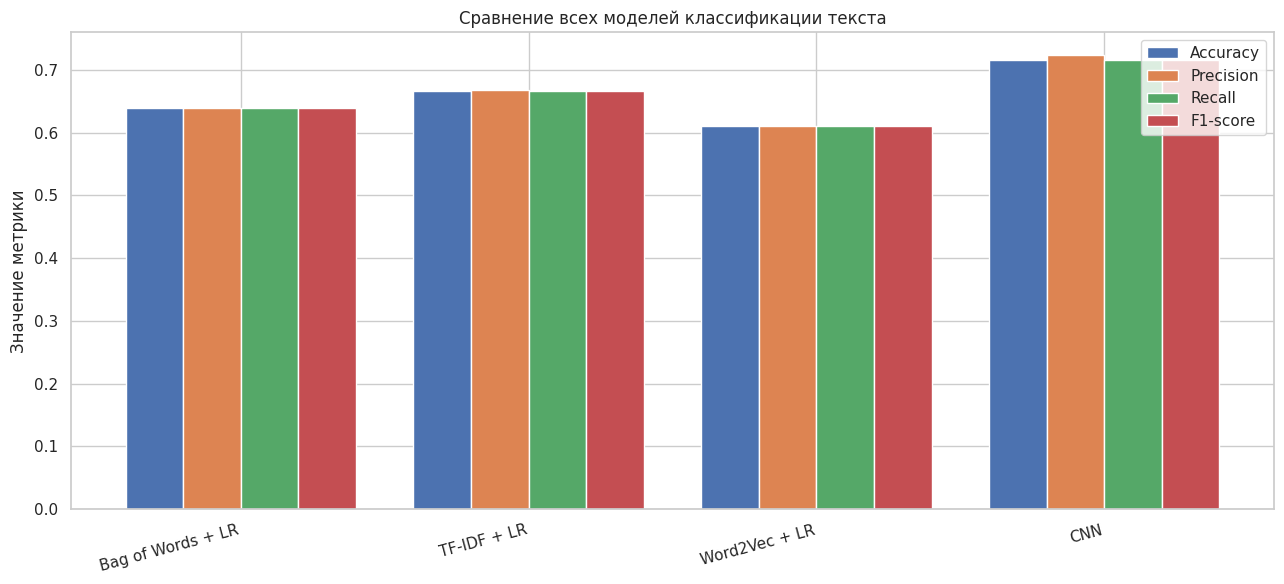

In [65]:
# 57. Финальный график сравнения всех моделей

plot_df = results_final.copy()

plt.figure(figsize=(13, 6))
x = np.arange(len(plot_df))
width = 0.2

plt.bar(x - 1.5 * width, plot_df["Accuracy"], width, label="Accuracy")
plt.bar(x - 0.5 * width, plot_df["Precision"], width, label="Precision")
plt.bar(x + 0.5 * width, plot_df["Recall"], width, label="Recall")
plt.bar(x + 1.5 * width, plot_df["F1-score"], width, label="F1-score")

plt.xticks(x, plot_df["Метод"], rotation=15, ha="right")
plt.ylabel("Значение метрики")
plt.title("Сравнение всех моделей классификации текста")
plt.legend()
plt.tight_layout()
plt.show()

In [67]:
# 58. Итоговый вывод

print("В ходе лабораторной работы был выполнен анализ текстового датасета Tweets.csv.")
print("На этапе предварительной обработки были удалены ссылки, упоминания пользователей, лишние символы, а текст был приведен к нижнему регистру.")
print("Также был проведен анализ распределения классов, длины текстов и частот слов, построены облака слов для всего корпуса и для отдельных классов.")

print("Для решения задачи классификации тональности были использованы методы Bag of Words, TF-IDF, Word2Vec и нейросетевая модель CNN.")
print("По результатам экспериментов метод TF-IDF показал более высокое качество по сравнению с Bag of Words.")
print("Модель Word2Vec в данной реализации показала более низкие результаты, чем классические методы векторизации.")
print("Наилучшее качество классификации показала нейросетевая модель CNN, которая получила самые высокие значения Accuracy, Precision, Recall и F1-score.")

print("Таким образом, для данного датасета наиболее эффективным оказался нейросетевой подход, а среди классических методов лучшим оказался TF-IDF.")
print("Методы NLP и машинного обучения позволяют эффективно решать задачу анализа тональности твитов.")

В ходе лабораторной работы был выполнен анализ текстового датасета Tweets.csv.
На этапе предварительной обработки были удалены ссылки, упоминания пользователей, лишние символы, а текст был приведен к нижнему регистру.
Также был проведен анализ распределения классов, длины текстов и частот слов, построены облака слов для всего корпуса и для отдельных классов.
Для решения задачи классификации тональности были использованы методы Bag of Words, TF-IDF, Word2Vec и нейросетевая модель CNN.
По результатам экспериментов метод TF-IDF показал более высокое качество по сравнению с Bag of Words.
Модель Word2Vec в данной реализации показала более низкие результаты, чем классические методы векторизации.
Наилучшее качество классификации показала нейросетевая модель CNN, которая получила самые высокие значения Accuracy, Precision, Recall и F1-score.
Таким образом, для данного датасета наиболее эффективным оказался нейросетевой подход, а среди классических методов лучшим оказался TF-IDF.
Методы NLP и м